In [1]:
import cv2
import numpy as np

video_path = 'CamA.MP4'
cap = cv2.VideoCapture(video_path)
y_start,y_end = 778, 970
x_start,x_end = 0, 1916

In [2]:
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    roi_frame = frame[y_start:y_end, x_start:x_end]
    gray = cv2.cvtColor(roi_frame, cv2.COLOR_BGR2GRAY)  # 轉灰階
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)         # 高斯濾波
    edges = cv2.Canny(blurred, 30, 100)                 # Canny邊緣偵測
    cv2.imshow('1. ROI Frame', roi_frame)
    cv2.imshow('2. Blurred Grayscale', blurred)
    cv2.imshow('3. Canny Edges', edges)

    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

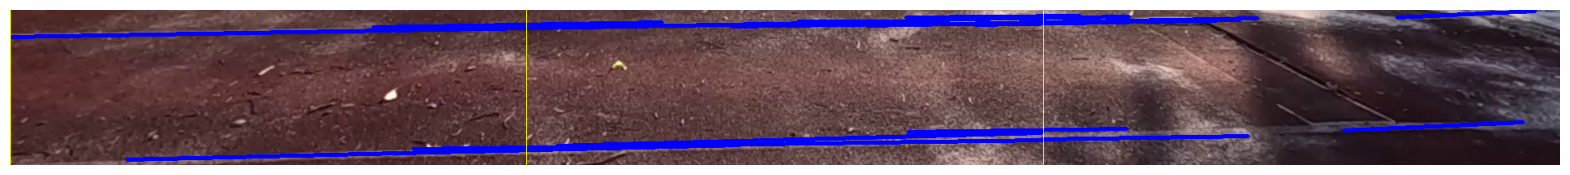

In [3]:
import math
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if ret:
    roi_frame = frame[y_start:y_end, x_start:x_end]
    img_h, img_w = roi_frame.shape[:2]

    # --- 前處理 ---
    gray = cv2.cvtColor(roi_frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)

    # --- 霍夫轉換 ---
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=50, minLineLength=150, maxLineGap=40)
    # --- 角度篩選---
    horizontal_lines = []
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            # 計算線段角度
            angle = math.degrees(math.atan2(y2 - y1, x2 - x1))
            abs_angle = abs(angle)
            if abs_angle > 90:
                abs_angle = 180 - abs_angle
            
            if abs_angle <= 10:
                # 統一方向：確保起點在左 (x1 < x2)，方便後續取極值
                if x1 > x2:
                    x1, y1, x2, y2 = x2, y2, x1, y1
                horizontal_lines.append([x1, y1, x2, y2])

    # --- 4. 文獻 2.3.1 適應性分群與合併演算法 ---
    merged_lines_img = roi_frame.copy()
    final_merged_lines = []
    
    # 步驟 1 & 2: 將畫面切分為左、中、右三個區域
    area_bounds = [
        (0, img_w // 3),                 # 左區
        (img_w // 3, 2 * img_w // 3),    # 中區
        (2 * img_w // 3, img_w)          # 右區
    ]

    for left_bound, right_bound in area_bounds:
        area_lines = []
        # 將水平線分發到三個區域 (利用線段中點 X 座標判斷)
        for line in horizontal_lines:
            cx = (line[0] + line[2]) / 2
            if left_bound <= cx < right_bound:
                area_lines.append(line)

        if not area_lines:
            continue

        # 依 Y 座標排序 (由上到下，從畫面遠處到近處)
        area_lines.sort(key=lambda l: (l[1] + l[3]) / 2)

        groups = []
        current_group = [area_lines[0]]

        for i in range(1, len(area_lines)):
            line = area_lines[i]
            ref_line = current_group[0] # 文獻提及選取代表性參考線

            y_center_line = (line[1] + line[3]) / 2
            y_center_ref = (ref_line[1] + ref_line[3]) / 2
            y_dist = abs(y_center_line - y_center_ref)

            # 步驟 3: 動態閾值 (Variable threshold)
            # 遠處 (Y值小) 跑道線較密，容許誤差小；近處 (Y值大) 跑道線較疏，容許誤差大
            # 公式：基礎誤差 + (當前Y座標 / 影像總高) * 縮放係數
            dynamic_threshold = 1.5 + (y_center_line / img_h) * 10

            if y_dist <= dynamic_threshold:
                current_group.append(line)
            else:
                groups.append(current_group)
                current_group = [line]
                
        groups.append(current_group)

        # 步驟 4: 合併同群組線段 (取最小 x1 與最大 x2，Y 值跟隨端點)
        for group in groups:
            min_x = float('inf')
            max_x = float('-inf')
            left_y, right_y = 0, 0

            for x1, y1, x2, y2 in group:
                if x1 < min_x:
                    min_x = x1
                    left_y = y1
                if x2 > max_x:
                    max_x = x2
                    right_y = y2

            merged_line = (int(min_x), int(left_y), int(max_x), int(right_y))
            final_merged_lines.append(merged_line)
            
            # 將合併後的代表線畫成藍色
            cv2.line(merged_lines_img, (merged_line[0], merged_line[1]), (merged_line[2], merged_line[3]), (255, 0, 0), 3)

        # 畫出三個區域的黃色分隔線，方便觀察
        cv2.line(merged_lines_img, (left_bound, 0), (left_bound, img_h), (0, 255, 255), 1)
        cv2.line(merged_lines_img, (right_bound, 0), (right_bound, img_h), (0, 255, 255), 1)

    # 利用 matplotlib 在 Jupyter 內顯示大圖
    plt.figure(figsize=(20, 8))
    plt.imshow(cv2.cvtColor(merged_lines_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
else:
    print("無法讀取影片幀。")

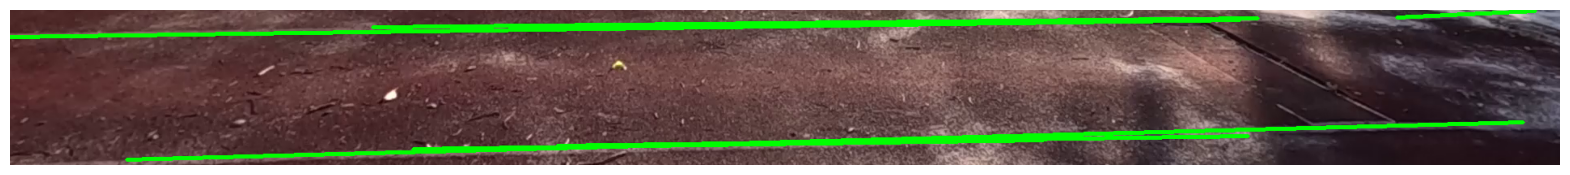

In [4]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if ret:
    roi_frame = frame[y_start:y_end, x_start:x_end]
    img_h, img_w = roi_frame.shape[:2]

    # 前處理
    gray = cv2.cvtColor(roi_frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)

    # 霍夫轉換
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=50, minLineLength=150, maxLineGap=40)
    
    horizontal_lines, vertical_lines = [], []
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            angle = math.degrees(math.atan2(y2 - y1, x2 - x1))
            abs_angle = abs(angle)
            if abs_angle > 90: abs_angle = 180 - abs_angle
            
            if abs_angle <= 10: # 水平線
                if x1 > x2: x1, y1, x2, y2 = x2, y2, x1, y1
                horizontal_lines.append([x1, y1, x2, y2])
            elif 80 <= abs_angle <= 100: # 垂直線
                vertical_lines.append([x1, y1, x2, y2])

    # 3. 水平線適應性分群與跨區連接 (Stage 1-5)
    final_merged_lines = []
    area_bounds = [(0, img_w // 3), (img_w // 3, 2 * img_w // 3), (2 * img_w // 3, img_w)]
    
    for left_bound, right_bound in area_bounds:
        area_lines = [l for l in horizontal_lines if left_bound <= (l[0]+l[2])/2 < right_bound]
        if not area_lines: continue
        area_lines.sort(key=lambda l: (l[1] + l[3]) / 2)
        groups = [[area_lines[0]]]
        for i in range(1, len(area_lines)):
            line = area_lines[i]
            y_dist = abs(((line[1] + line[3]) / 2) - ((groups[-1][0][1] + groups[-1][0][3]) / 2))
            dynamic_threshold = 1.5 + ((line[1] + line[3]) / 2 / img_h) * 10
            if y_dist <= dynamic_threshold: groups[-1].append(line)
            else: groups.append([line])
        for group in groups:
            final_merged_lines.append([min(l[0] for l in group), [l[1] for l in group if l[0] == min(l[0] for l in group)][0], 
                                      max(l[2] for l in group), [l[3] for l in group if l[2] == max(l[2] for l in group)][0]])

    connected_final = []
    used = [False] * len(final_merged_lines)
    for i in range(len(final_merged_lines)):
        if used[i]: continue
        curr = list(final_merged_lines[i])
        used[i] = True
        for j in range(len(final_merged_lines)):
            if used[j]: continue
            target = final_merged_lines[j]
            if abs(((curr[1]+curr[3])/2) - ((target[1]+target[3])/2)) < 30 and abs(curr[2] - target[0]) < 300:
                curr[2], curr[3] = target[2], target[3]
                used[j] = True
        connected_final.append(curr)

    # 4. 垂直線篩選與消失點計算
    vertical_lines.sort(key=lambda l: math.sqrt((l[2]-l[0])**2 + (l[3]-l[1])**2), reverse=True)
    dominant_v = vertical_lines[:2] # 取兩條最長垂直線
    
    vp = None
    if len(dominant_v) >= 2:
        l1, l2 = dominant_v[0], dominant_v[1]
        A1, B1, C1 = l1[3]-l1[1], l1[0]-l1[2], (l1[3]-l1[1])*l1[0] + (l1[0]-l1[2])*l1[1]
        A2, B2, C2 = l2[3]-l2[1], l2[0]-l2[2], (l2[3]-l2[1])*l2[0] + (l2[0]-l2[2])*l2[1]
        det = A1*B2 - A2*B1
        if det != 0: vp = (int((B2*C1 - B1*C2)/det), int((A1*C2 - A2*C1)/det))

    # 5. 繪製最終結果
    res_img = roi_frame.copy()
    for line in connected_final:
        cv2.line(res_img, (line[0], line[1]), (line[2], line[3]), (0, 255, 0), 3)
    if vp: cv2.circle(res_img, vp, 10, (0, 0, 255), -1)

    plt.figure(figsize=(20, 8))
    plt.imshow(cv2.cvtColor(res_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

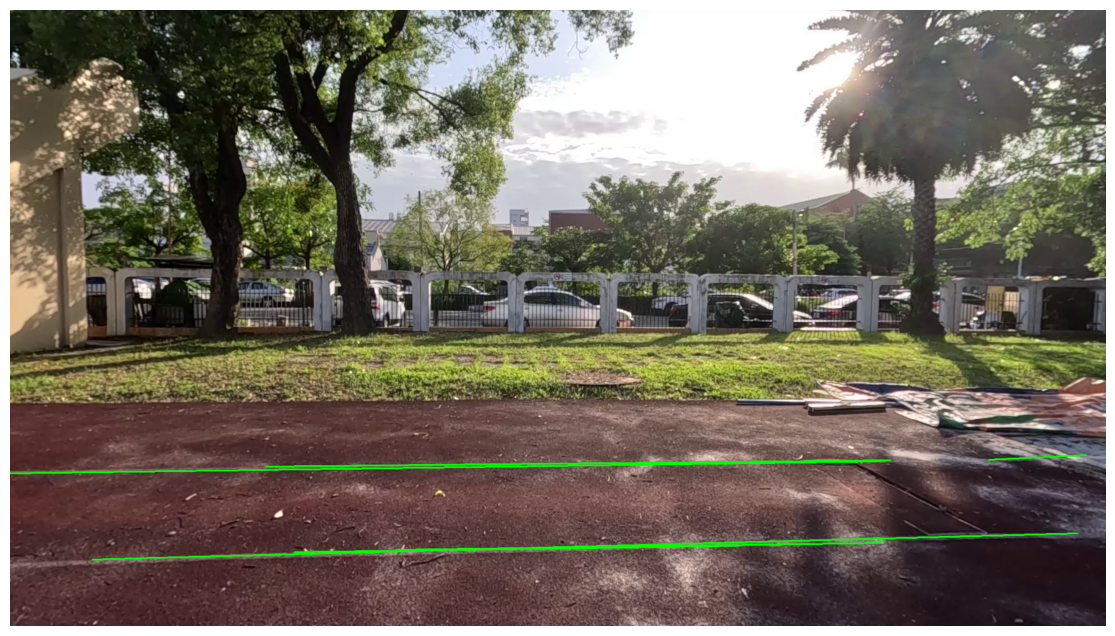

In [5]:
import numpy as np
import cv2
import math
import matplotlib.pyplot as plt


def get_intersection(l1, l2):
    A1, B1 = l1[3]-l1[1], l1[0]-l1[2]
    C1 = A1*l1[0] + B1*l1[1]
    A2, B2 = l2[3]-l2[1], l2[0]-l2[2]
    C2 = A2*l2[0] + B2*l2[1]
    det = A1*B2 - A2*B1
    if det != 0:
        return (int((B2*C1 - B1*C2)/det), int((A1*C2 - A2*C1)/det))
    return None

vertical_lines = []
if 'lines' in locals() and lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle = math.degrees(math.atan2(y2 - y1, x2 - x1))
        abs_angle = abs(angle)
        if abs_angle > 90: abs_angle = 180 - abs_angle
        # 放寬垂直線認定標準為 65~90 度
        if 65 <= abs_angle <= 90: 
            vertical_lines.append([x1, y1, x2, y2])

# 分左右並取最長
img_w = roi_frame.shape[1]
left_v_lines = [l for l in vertical_lines if (l[0]+l[2])/2 < img_w * 0.45]
right_v_lines = [l for l in vertical_lines if (l[0]+l[2])/2 > img_w * 0.55]

def line_len(l): return math.sqrt((l[2]-l[0])**2 + (l[3]-l[1])**2)
left_v_lines.sort(key=line_len, reverse=True)
right_v_lines.sort(key=line_len, reverse=True)

dominant_v = []
if left_v_lines: dominant_v.append(left_v_lines[0])
if right_v_lines: dominant_v.append(right_v_lines[0])

# 計算消失點 vp
vp = None
if len(dominant_v) >= 2:
    vp = get_intersection(dominant_v[0], dominant_v[1])

connected_final.sort(key=lambda l: (l[1]+l[3])/2)
idx_top = 3 if len(connected_final) >= 5 else 0
idx_bottom = 4 if len(connected_final) >= 5 else -1

pt_tl, pt_tr, pt_bl, pt_br = None, None, None, None

if len(connected_final) >= 2 and len(dominant_v) >= 2:
    line_top = connected_final[idx_top]
    line_bottom = connected_final[idx_bottom]
    
    pt_tl = get_intersection(line_top, dominant_v[0])    # 左上
    pt_tr = get_intersection(line_top, dominant_v[1])    # 右上
    pt_bl = get_intersection(line_bottom, dominant_v[0]) # 左下
    pt_br = get_intersection(line_bottom, dominant_v[1]) # 右下


full_img_draw = frame.copy() 
img_h, img_w = full_img_draw.shape[:2]

src_points_full = []
for pt in [pt_tl, pt_tr, pt_bl, pt_br]:
    if pt is not None:
        full_x = pt[0] + x_start
        full_y = pt[1] + y_start
        src_points_full.append([full_x, full_y])
        cv2.circle(full_img_draw, (full_x, full_y), 8, (0, 255, 255), -1) 

if len(dominant_v) >= 2:
    for i in range(2):
        pt1_x, pt1_y = dominant_v[i][0] + x_start, dominant_v[i][1] + y_start
        pt2_x, pt2_y = dominant_v[i][2] + x_start, dominant_v[i][3] + y_start
        if pt1_y != pt2_y:
            m_inv = (pt1_x - pt2_x) / (pt1_y - pt2_y)
            c_inv = pt1_x - m_inv * pt1_y
            x_top = int(m_inv * 0 + c_inv)
            x_bottom = int(m_inv * img_h + c_inv)           
            cv2.line(full_img_draw, (x_top, 0), (x_bottom, img_h), (0, 0, 255), 3)

# --- 轉換並畫出消失點 ---
vp_full = None
if vp is not None:
    vp_full = (vp[0] + x_start, vp[1] + y_start)
    cv2.circle(full_img_draw, vp_full, 12, (255, 0, 255), -1) 

# --- 畫出水平跑道線 ---
for line in connected_final:
    full_x1, full_y1 = line[0] + x_start, line[1] + y_start
    full_x2, full_y2 = line[2] + x_start, line[3] + y_start
    cv2.line(full_img_draw, (full_x1, full_y1), (full_x2, full_y2), (0, 255, 0), 2)

plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(full_img_draw, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

🎯 成功計算出消失點 (ROI座標): (958, -244)


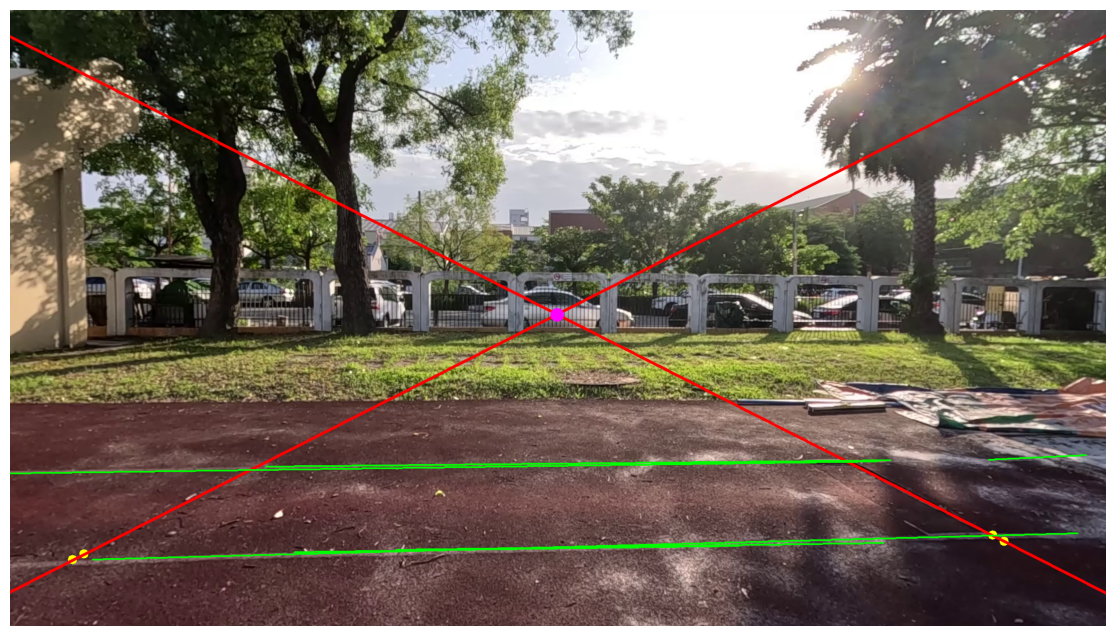

In [6]:
import numpy as np
import cv2
import math
import matplotlib.pyplot as plt

def get_intersection(l1, l2):
    A1, B1 = l1[3]-l1[1], l1[0]-l1[2]
    C1 = A1*l1[0] + B1*l1[1]
    A2, B2 = l2[3]-l2[1], l2[0]-l2[2]
    C2 = A2*l2[0] + B2*l2[1]
    det = A1*B2 - A2*B1
    if det != 0:
        return (int((B2*C1 - B1*C2)/det), int((A1*C2 - A2*C1)/det))
    return None

h_angles = []
for line in connected_final:
    angle = math.degrees(math.atan2(line[3] - line[1], line[2] - line[0]))
    h_angles.append(abs(angle))
base_angle = np.mean(h_angles) if h_angles else 0

left_v_candidates = []
right_v_candidates = []
img_w = roi_frame.shape[1]
img_h = roi_frame.shape[0]
mid_x = img_w * 0.5

if 'lines' in locals() and lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle = math.degrees(math.atan2(y2 - y1, x2 - x1))
        abs_angle = abs(angle)
        if abs_angle > 90: abs_angle = 180 - abs_angle
        
        # 篩選大於水平基準的縱向線
        if abs_angle > (base_angle + 2.0): 
            length = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            if length > 5:
                line_data = {'line': [x1, y1, x2, y2], 'length': length}
                x_mid = (x1 + x2) / 2
                if x_mid < mid_x:
                    left_v_candidates.append(line_data)
                else:
                    right_v_candidates.append(line_data)

dominant_v = []

# 分別選取左右兩側最長的真實線段
real_left = None
real_right = None

if left_v_candidates:
    left_v_candidates.sort(key=lambda x: x['length'], reverse=True)
    real_left = left_v_candidates[0]['line']

if right_v_candidates:
    right_v_candidates.sort(key=lambda x: x['length'], reverse=True)
    real_right = right_v_candidates[0]['line']

# 🔑 核心防呆邏輯：如果某個半幅斷線，利用對稱幾何自動生成另一邊的邊界線
if real_left is not None and real_right is not None:
    dominant_v.append(real_left)
    dominant_v.append(real_right)
    print("✅ 成功抓取左右兩側真實邊界線！")
elif real_left is None and real_right is not None:
    # 只有右邊有線：將右邊的線水平翻轉到左邊對稱位置
    r = real_right
    # 關於中線對稱：新X = 2 * mid_x - 原X
    l_x1 = int(2 * mid_x - r[2])
    l_y1 = r[3]
    l_x2 = int(2 * mid_x - r[0])
    l_y2 = r[1]
    virtual_left = [l_x1, l_y1, l_x2, l_y2]
    dominant_v.append(virtual_left)
    dominant_v.append(r)

elif real_right is None and real_left is not None:
    # 只有左邊有線：將左邊的線水平翻轉到右邊對稱位置
    l = real_left
    r_x1 = int(2 * mid_x - l[2])
    r_y1 = l[3]
    r_x2 = int(2 * mid_x - l[0])
    r_y2 = l[1]
    virtual_right = [r_x1, r_y1, r_x2, r_y2]
    dominant_v.append(l)
    dominant_v.append(virtual_right)

# ==========================================
# 2. 消失點與 4 個 Homography 參考點計算
# ==========================================
vp = None
if len(dominant_v) >= 2:
    vp = get_intersection(dominant_v[0], dominant_v[1])
    print(f"🎯 成功計算出消失點 (ROI座標): {vp}")

connected_final.sort(key=lambda l: (l[1]+l[3])/2)
idx_top = 3 if len(connected_final) >= 5 else 0
idx_bottom = 4 if len(connected_final) >= 5 else -1

pt_tl, pt_tr, pt_bl, pt_br = None, None, None, None
if len(connected_final) >= 2 and len(dominant_v) >= 2:
    line_top = connected_final[idx_top]
    line_bottom = connected_final[idx_bottom]
    
    pt_tl = get_intersection(line_top, dominant_v[0])
    pt_tr = get_intersection(line_top, dominant_v[1])
    pt_bl = get_intersection(line_bottom, dominant_v[0])
    pt_br = get_intersection(line_bottom, dominant_v[1])

# ==========================================
# 3. 繪製完全對應 Figure 7 的無限延伸大圖
# ==========================================
full_img_draw = frame.copy() 
full_h, full_w = full_img_draw.shape[:2]

# 畫出 4 個黃色參考交點
for pt in [pt_tl, pt_tr, pt_bl, pt_br]:
    if pt is not None:
        cv2.circle(full_img_draw, (pt[0] + x_start, pt[1] + y_start), 8, (0, 255, 255), -1) 

# 畫出無限延伸的紅色直線 (貫穿畫面形成交叉)
if len(dominant_v) >= 2:
    for i in range(2):
        pt1_x, pt1_y = dominant_v[i][0] + x_start, dominant_v[i][1] + y_start
        pt2_x, pt2_y = dominant_v[i][2] + x_start, dominant_v[i][3] + y_start
        if pt1_y != pt2_y:
            m_inv = (pt1_x - pt2_x) / (pt1_y - pt2_y)
            c_inv = pt1_x - m_inv * pt1_y
            x_top = int(m_inv * 0 + c_inv)
            x_bottom = int(m_inv * full_h + c_inv)           
            cv2.line(full_img_draw, (x_top, 0), (x_bottom, full_h), (0, 0, 255), 3)

# 畫出粉紅色消失點
if vp is not None:
    vp_full = (vp[0] + x_start, vp[1] + y_start)
    cv2.circle(full_img_draw, vp_full, 12, (255, 0, 255), -1) 

# 畫出綠色水平跑道線
for line in connected_final:
    full_x1, full_y1 = line[0] + x_start, line[1] + y_start
    full_x2, full_y2 = line[2] + x_start, line[3] + y_start
    cv2.line(full_img_draw, (full_x1, full_y1), (full_x2, full_y2), (0, 255, 0), 2)

plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(full_img_draw, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()